device: cpu
loading: poet.song.40000.json
loading: poet.song.41000.json
loading: poet.song.42000.json
loading: poet.song.43000.json
poems: 907
vocab: 2835
epoch 1, loss=7.3615
epoch 2, loss=7.0171
epoch 3, loss=6.9901
epoch 4, loss=6.9769
epoch 5, loss=6.9717
epoch 6, loss=6.9789
epoch 7, loss=6.9750
epoch 8, loss=6.9266
epoch 9, loss=6.7039
epoch 10, loss=6.2046
epoch 11, loss=5.6008
epoch 12, loss=5.0013
epoch 13, loss=4.3683
epoch 14, loss=3.6857
epoch 15, loss=3.0424
epoch 16, loss=2.4222
epoch 17, loss=1.8595
epoch 18, loss=1.4027
epoch 19, loss=1.0249
epoch 20, loss=0.7437
epoch 21, loss=0.5442
epoch 22, loss=0.4147
epoch 23, loss=0.3407
epoch 24, loss=0.2915
epoch 25, loss=0.2527
epoch 26, loss=0.2295
epoch 27, loss=0.2125
epoch 28, loss=0.1970
epoch 29, loss=0.1879
epoch 30, loss=0.1762
epoch 31, loss=0.1636
epoch 32, loss=0.1643
epoch 33, loss=0.1616
epoch 34, loss=0.1602
epoch 35, loss=0.1452
epoch 36, loss=0.1417
epoch 37, loss=0.1359
epoch 38, loss=0.1329
epoch 39, loss=0.1

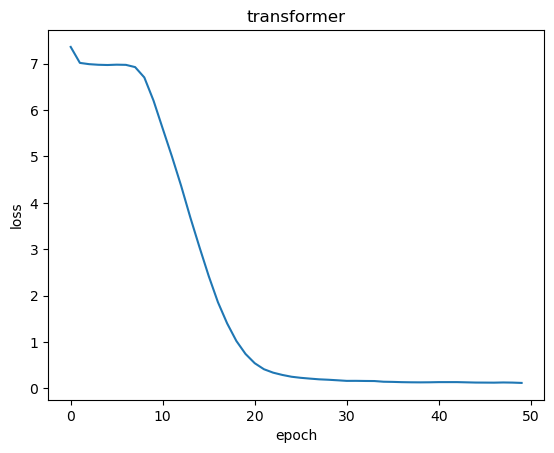


生成结果：

明月已誰謂無舟，
夜行役走埃扁舟。
夜半燈花殘陽平，
地暖何用江上月。


In [1]:
import os
import json
import re
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import Dataset
from torch.utils.data import DataLoader


################################################
# 在这里改模型
################################################

# model_type = "rnn"
# model_type="lstm"
model_type="transformer"

data_dir = "./data"

epochs = 50

device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("device:", device)


################################################
# 数据处理
################################################

def clean_text(paragraphs):

    text = ''.join(paragraphs)

    text = re.sub(
        '[，。！？、；：]',
        '',
        text
    )

    return text


def load_poems(data_dir):

    poems = []

    for file in os.listdir(data_dir):

        if not file.endswith(".json"):
            continue

        print("loading:", file)

        path = os.path.join(
            data_dir,
            file
        )

        data = json.load(
            open(
                path,
                "r",
                encoding="utf8"
            )
        )

        for item in data:

            poem = clean_text(
                item["paragraphs"]
            )

            # 七言绝句
            if len(poem) == 28:

                poems.append(
                    poem
                )

    print("poems:", len(poems))

    return poems


################################################
# Dataset
################################################

class PoemDataset(Dataset):

    def __init__(self, poems):

        self.poems = poems

        chars = sorted(
            list(
                set(
                    ''.join(poems)
                )
            )
        )

        self.char2idx = {
            c:i
            for i,c in enumerate(chars)
        }

        self.idx2char = {
            i:c
            for c,i in self.char2idx.items()
        }

        self.vocab_size = len(chars)

        print(
            "vocab:",
            self.vocab_size
        )


    def encode(self,text):

        return [
            self.char2idx[c]
            for c in text
        ]


    def __len__(self):

        return len(
            self.poems
        )


    def __getitem__(self,idx):

        poem = self.poems[idx]

        ids = self.encode(
            poem
        )

        x = torch.tensor(
            ids[:-1],
            dtype=torch.long
        )

        y = torch.tensor(
            ids[1:],
            dtype=torch.long
        )

        return x,y


################################################
# 模型
################################################

class RNNModel(nn.Module):

    def __init__(self,vocab_size):

        super().__init__()

        self.embed = nn.Embedding(
            vocab_size,
            128
        )

        self.rnn = nn.RNN(
            128,
            256,
            num_layers=2,
            batch_first=True
        )

        self.fc = nn.Linear(
            256,
            vocab_size
        )


    def forward(self,x):

        x = self.embed(x)

        out,_ = self.rnn(x)

        out = self.fc(out)

        return out


class LSTMModel(nn.Module):

    def __init__(self,vocab_size):

        super().__init__()

        self.embed = nn.Embedding(
            vocab_size,
            128
        )

        self.rnn = nn.LSTM(
            128,
            256,
            num_layers=2,
            batch_first=True
        )

        self.fc = nn.Linear(
            256,
            vocab_size
        )


    def forward(self,x):

        x = self.embed(x)

        out,_ = self.rnn(x)

        out = self.fc(out)

        return out


class TransformerModel(nn.Module):

    def __init__(self,vocab_size):

        super().__init__()

        self.embed = nn.Embedding(
            vocab_size,
            256
        )

        layer = nn.TransformerEncoderLayer(
            d_model=256,
            nhead=8,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            layer,
            num_layers=4
        )

        self.fc = nn.Linear(
            256,
            vocab_size
        )


    def forward(self,x):

        x = self.embed(x)

        seq_len = x.shape[1]

        mask = torch.triu(
            torch.ones(
                seq_len,
                seq_len,
                device=x.device
            ),
            diagonal=1
        ).bool()

        x = self.transformer(
            x,
            mask=mask
        )

        x = self.fc(x)

        return x


################################################
# 加载数据
################################################

poems = load_poems(
    data_dir
)

dataset = PoemDataset(
    poems
)

loader = DataLoader(

    dataset,

    batch_size=64,

    shuffle=True
)


################################################
# 选择模型
################################################

if model_type=="rnn":

    model = RNNModel(
        dataset.vocab_size
    )

elif model_type=="lstm":

    model = LSTMModel(
        dataset.vocab_size
    )

else:

    model = TransformerModel(
        dataset.vocab_size
    )


model = model.to(
    device
)


################################################
# 训练
################################################

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

losses = []

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for x,y in loader:

        x = x.to(device)

        y = y.to(device)

        pred = model(x)

        loss = criterion(

            pred.reshape(
                -1,
                pred.shape[-1]
            ),

            y.reshape(-1)
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()


    total_loss /= len(
        loader
    )

    losses.append(
        total_loss
    )

    print(
        f"epoch {epoch+1}, loss={total_loss:.4f}"
    )


################################################
# loss图
################################################

plt.figure()

plt.plot(
    losses
)

plt.title(
    model_type
)

plt.xlabel(
    "epoch"
)

plt.ylabel(
    "loss"
)

plt.show()


################################################
# 生成古诗
################################################

model.eval()

result = list(
    "明月"
)

with torch.no_grad():

    for _ in range(
        28-len(result)
    ):

        ids = dataset.encode(
            result
        )

        x = torch.tensor(
            ids,
            dtype=torch.long
        ).unsqueeze(0)

        x = x.to(
            device
        )

        pred = model(x)

        next_id = pred[
            0,-1
        ].argmax()

        next_char = (
            dataset.idx2char[
                next_id.item()
            ]
        )

        result.append(
            next_char
        )


poem = ''.join(
    result
)

print("\n生成结果：\n")

print(
    poem[:7]+"，"
)

print(
    poem[7:14]+"。"
)

print(
    poem[14:21]+"，"
)

print(
    poem[21:28]+"。"
)

# Homework3：实现古诗生成
姓名：唐晓刚
学号：BC25038003

本项目实现三种序列生成模型，用于生成固定格式的中文古诗：

- 基础循环神经网络（RNN）
- 长短期记忆网络（LSTM）
- Transformer

模型以：

> **“明月”**

作为起始词，自动生成一首 **七言绝句**。

---

# 一、导入所需库

```python
import os
import json
import re
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import Dataset
from torch.utils.data import DataLoader
```

---

# 二、参数设置

设置模型类型、训练轮数以及运行设备。

```python
# model_type = "rnn"
# model_type = "lstm"
model_type = "transformer"     # 选择模型

data_dir = "./data"            # 数据目录

epochs = 50                    # 训练轮数

# 优先使用GPU
device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("device:", device)
```

---

# 三、数据预处理

去除古诗中的标点符号，只保留七言绝句。

## 1. 去除标点

```python
def clean_text(paragraphs):

    # 列表拼接成字符串
    text = ''.join(paragraphs)

    # 删除中文标点
    text = re.sub(
        '[，。！？、；：]',
        '',
        text
    )

    return text
```

---

## 2. 读取古诗数据

七言绝句：

> 4 × 7 = 28字

```python
def load_poems(data_dir):

    poems = []

    # 遍历所有json文件
    for file in os.listdir(data_dir):

        if not file.endswith(".json"):
            continue

        path = os.path.join(
            data_dir,
            file
        )

        # 读取json
        data = json.load(
            open(
                path,
                "r",
                encoding="utf8"
            )
        )

        # 遍历每首诗
        for item in data:

            # 去掉标点
            poem = clean_text(
                item["paragraphs"]
            )

            # 筛选七言绝句
            if len(poem) == 28:

                poems.append(
                    poem
                )

    return poems
```

---

# 四、构建数据集

将汉字转换为数字，并构造训练样本。

例如：

```text
明 → 100
月 → 58
山 → 203
```

---

## Dataset定义

```python
class PoemDataset(Dataset):

    def __init__(self, poems):

        # 保存古诗
        self.poems = poems

        # 提取所有汉字
        chars = sorted(
            list(
                set(
                    ''.join(poems)
                )
            )
        )

        # 字 -> 数字
        self.char2idx = {
            c:i
            for i,c in enumerate(chars)
        }

        # 数字 -> 字
        self.idx2char = {
            i:c
            for c,i in self.char2idx.items()
        }

        # 字典大小
        self.vocab_size = len(chars)

        print(
            "vocab:",
            self.vocab_size
        )


    # 编码
    def encode(self,text):

        return [
            self.char2idx[c]
            for c in text
        ]


    # 数据集大小
    def __len__(self):

        return len(
            self.poems
        )


    # 构造训练样本
    def __getitem__(self,idx):

        poem = self.poems[idx]

        ids = self.encode(
            poem
        )

        # 输入
        x = torch.tensor(
            ids[:-1],
            dtype=torch.long
        )

        # 标签
        y = torch.tensor(
            ids[1:],
            dtype=torch.long
        )

        return x,y
```

训练目标：

```text
输入：明月松间照
标签：月松间照清
```

即：

> 当前字预测下一个字。

---

# 五、模型构建

实现三种模型。

---

## 1. RNN

网络结构：

```text
输入 → Embedding → RNN → 全连接层
```

```python
class RNNModel(nn.Module):

    def __init__(self,vocab_size):

        super().__init__()

        self.embed = nn.Embedding(
            vocab_size,
            128
        )

        self.rnn = nn.RNN(
            128,
            256,
            num_layers=2,
            batch_first=True
        )

        self.fc = nn.Linear(
            256,
            vocab_size
        )


    def forward(self,x):

        x = self.embed(x)

        out,_ = self.rnn(x)

        out = self.fc(out)

        return out
```

---

## 2. LSTM

网络结构：

```text
输入 → Embedding → LSTM → 全连接层
```

```python
class LSTMModel(nn.Module):

    def __init__(self,vocab_size):

        super().__init__()

        self.embed = nn.Embedding(
            vocab_size,
            128
        )

        self.rnn = nn.LSTM(
            128,
            256,
            num_layers=2,
            batch_first=True
        )

        self.fc = nn.Linear(
            256,
            vocab_size
        )


    def forward(self,x):

        x = self.embed(x)

        out,_ = self.rnn(x)

        out = self.fc(out)

        return out
```

---

## 3. Transformer

网络结构：

```text
输入 → Embedding → Self-Attention → 全连接层
```

```python
class TransformerModel(nn.Module):

    def __init__(self,vocab_size):

        super().__init__()

        self.embed = nn.Embedding(
            vocab_size,
            256
        )

        # 单层Transformer
        layer = nn.TransformerEncoderLayer(
            d_model=256,
            nhead=8,
            batch_first=True
        )

        # 堆叠4层
        self.transformer = nn.TransformerEncoder(
            layer,
            num_layers=4
        )

        self.fc = nn.Linear(
            256,
            vocab_size
        )


    def forward(self,x):

        x = self.embed(x)

        seq_len = x.shape[1]

        # 因果mask
        mask = torch.triu(
            torch.ones(
                seq_len,
                seq_len,
                device=x.device
            ),
            diagonal=1
        ).bool()

        x = self.transformer(
            x,
            mask=mask
        )

        x = self.fc(x)

        return x
```

---

# 六、加载数据并选择模型

```python
poems = load_poems(
    data_dir
)

dataset = PoemDataset(
    poems
)

loader = DataLoader(

    dataset,

    batch_size=64,

    shuffle=True
)


if model_type=="rnn":

    model = RNNModel(
        dataset.vocab_size
    )

elif model_type=="lstm":

    model = LSTMModel(
        dataset.vocab_size
    )

else:

    model = TransformerModel(
        dataset.vocab_size
    )


model = model.to(
    device
)
```

---

# 七、模型训练

使用：

- CrossEntropyLoss
- Adam

```python
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

losses = []


for epoch in range(epochs):

    model.train()

    total_loss = 0

    for x,y in loader:

        x = x.to(device)

        y = y.to(device)

        # 前向传播
        pred = model(x)

        # loss
        loss = criterion(

            pred.reshape(
                -1,
                pred.shape[-1]
            ),

            y.reshape(-1)
        )

        # 反向传播
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()


    total_loss /= len(
        loader
    )

    losses.append(
        total_loss
    )

    print(
        f"epoch {epoch+1}, loss={total_loss:.4f}"
    )
```

---

# 八、Loss可视化

```python
plt.figure()

plt.plot(
    losses
)

plt.title(
    model_type
)

plt.xlabel(
    "epoch"
)

plt.ylabel(
    "loss"
)

plt.show()
```

---

# 九、古诗生成

以：

> “明月”

开头生成。

```python
model.eval()

result = list(
    "明月"
)


with torch.no_grad():

    for _ in range(
        28-len(result)
    ):

        ids = dataset.encode(
            result
        )

        x = torch.tensor(
            ids,
            dtype=torch.long
        ).unsqueeze(0)

        x = x.to(
            device
        )

        pred = model(x)

        next_id = pred[
            0,-1
        ].argmax()

        next_char = (
            dataset.idx2char[
                next_id.item()
            ]
        )

        result.append(
            next_char
        )


poem = ''.join(
    result
)

print("\n生成结果：\n")

print(
    poem[:7]+"，"
)

print(
    poem[7:14]+"。"
)

print(
    poem[14:21]+"，"
)

print(
    poem[21:28]+"。"
)
```

---

# 十、生成结果

## 1. RNN
```text
明月都上生不是，
山間一度來傷復。
應枯也得一朝開，
窗有無心只自廬。
```
<img src="RNN.png" alt="alt text" width="800">


## 2. LSTM
```text
明月雨巖下石氣，
勢崇人却何直學。
身庭中一任傍休，
豈怪山壺酒助落。
```
<img src="LSTM.png" alt="alt text" width="800">


## 3. transformer：

```text
明月已破三月來，
更飲一樽罍爲得。
新詩索獻酬登臨，
斜日遠方得趣只。
```
<img src="transformer.png" alt="alt text" width="800">
